# Are ECB GDP forecasts more moderate than realized outcomes?

This notebook retrieves the full historical panel of genuine **June and December**
ECB/Eurosystem country forecast vintages from the MPD—not only December 2025—and
matches each vintage to the corresponding latest-vintage realized annual real-GDP
growth outcome from MNA.

The notebook is deliberately audit-friendly: it first shows forecast-vintage coverage,
the matched observation panel, country long-run histories, and consecutive-vintage
revision paths. It then presents descriptive moderation patterns and the country-level
target-year bootstrap tests.

**Starting point inspected:** [`ecb_data_public.ipynb`](https://github.com/at621/snippets/blob/main/ecb_data_public.ipynb).
That source notebook demonstrates the ECB API using a single pinned December 2025
projection round. The analysis below extends the same API approach to all available
historical June/December MPD rounds. ECB country forecasts do not cover every EU member;
unavailable countries remain explicit and are never replaced with another institution's
forecasts.


In [1]:
from io import BytesIO
from urllib.request import Request, urlopen
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

API = "https://data-api.ecb.europa.eu/service/data"
EU = {
    "AT": "Austria", "BE": "Belgium", "BG": "Bulgaria", "HR": "Croatia",
    "CY": "Cyprus", "CZ": "Czechia", "DE": "Germany", "DK": "Denmark",
    "EE": "Estonia", "FI": "Finland", "FR": "France", "GR": "Greece",
    "HU": "Hungary", "IE": "Ireland", "IT": "Italy", "LT": "Lithuania",
    "LU": "Luxembourg", "LV": "Latvia", "MT": "Malta", "NL": "Netherlands",
    "PL": "Poland", "PT": "Portugal", "RO": "Romania", "SE": "Sweden",
    "SI": "Slovenia", "SK": "Slovakia", "ES": "Spain",
}
HORIZONS = (1, 2, 3)
BOOTSTRAPS = 5_000
MIN_TARGET_YEARS = 4


def fetch_ecb_csv(flow, key, retries=4):
    """Retrieve one ECB SDMX-CSV query without reading or writing local files."""
    url = f"{API}/{flow}/{key}?format=csvdata"
    last_error = None
    for attempt in range(retries):
        try:
            request = Request(url, headers={"User-Agent": "ecb-gdp-moderation-notebook/1.0"})
            with urlopen(request, timeout=120) as response:
                return pd.read_csv(BytesIO(response.read()), low_memory=False)
        except Exception as exc:
            last_error = exc
            if attempt + 1 < retries:
                time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"ECB query failed after {retries} attempts: {url}") from last_error


def projection_month(code):
    """Country MPD vintages use G=June and A=December."""
    return {"G": 6, "A": 12}[code[0]]


In [2]:
# Bulk queries: annual real-GDP-growth forecasts and annual chain-linked-volume GDP.
mpd_raw = fetch_ecb_csv("MPD", "A..YER.A..0000")
mna_raw = fetch_ecb_csv(
    "MNA", "A.N..W2.S1.S1.B.B1GQ._Z._Z._Z.EUR.LR.N"
)

# Preserve each genuine June/December country forecast vintage.  The MPD gives a
# projection month, not a day, so forecast_date uses the first day of that month.
forecast = mpd_raw.loc[
    mpd_raw["REF_AREA"].isin(EU)
    & mpd_raw["PD_SEAS_EX"].astype(str).str.fullmatch(r"[AG]\d{2}")
].copy()
forecast["forecast_year"] = 2000 + forecast["PD_SEAS_EX"].str[1:].astype(int)
forecast["forecast_month"] = forecast["PD_SEAS_EX"].map(projection_month)
forecast["forecast_date"] = pd.to_datetime(
    dict(year=forecast["forecast_year"], month=forecast["forecast_month"], day=1)
)
forecast["target_year"] = pd.to_numeric(forecast["TIME_PERIOD"], errors="coerce")
forecast["forecast_horizon"] = forecast["target_year"] - forecast["forecast_year"]
forecast["forecast_gdp_growth"] = pd.to_numeric(forecast["OBS_VALUE"], errors="coerce")
forecast = forecast.loc[
    forecast["forecast_horizon"].isin(HORIZONS)
    & forecast["forecast_gdp_growth"].notna()
    & forecast["OBS_STATUS"].eq("F")
].rename(columns={"REF_AREA": "country"})
forecast["target_year"] = forecast["target_year"].astype(int)
forecast["forecast_horizon"] = forecast["forecast_horizon"].astype(int)

forecast_key = ["country", "forecast_date", "target_year", "forecast_horizon"]
if forecast.duplicated(forecast_key).any():
    raise AssertionError("Duplicate country-vintage-target-horizon forecasts found")

# Latest-vintage realized outcomes: annual real GDP at market prices, chain-linked
# volume, converted to annual percentage growth only across consecutive years.
realized = mna_raw.loc[mna_raw["REF_AREA"].isin(EU)].copy()
realized["target_year"] = pd.to_numeric(realized["TIME_PERIOD"], errors="coerce")
realized["gdp_volume"] = pd.to_numeric(realized["OBS_VALUE"], errors="coerce")
realized = realized.dropna(subset=["target_year", "gdp_volume"]).rename(
    columns={"REF_AREA": "country"}
)
realized["target_year"] = realized["target_year"].astype(int)
realized = realized.sort_values(["country", "target_year"])
year_step = realized.groupby("country")["target_year"].diff()
realized["realized_gdp_growth"] = (
    realized.groupby("country")["gdp_volume"].pct_change(fill_method=None) * 100
).where(year_step.eq(1))
realized_growth = realized.dropna(subset=["realized_gdp_growth"])[
    ["country", "target_year", "realized_gdp_growth"]
].copy()

# One retrospective long-run anchor per country, using every consecutive annual
# growth observation available in the selected MNA series.
long_run = realized_growth.groupby("country").agg(
    country_long_run_average=("realized_gdp_growth", "mean"),
    long_run_start=("target_year", "min"),
    long_run_end=("target_year", "max"),
    long_run_n=("target_year", "size"),
).reset_index()

analysis_data = (
    forecast[forecast_key + ["forecast_gdp_growth"]]
    .merge(realized_growth, on=["country", "target_year"], how="inner", validate="many_to_one")
    .merge(long_run, on="country", how="left", validate="many_to_one")
    .sort_values(forecast_key)
    .reset_index(drop=True)
)
analysis_data["forecast_deviation"] = (
    analysis_data["forecast_gdp_growth"]
    - analysis_data["country_long_run_average"]
).abs()
analysis_data["realized_deviation"] = (
    analysis_data["realized_gdp_growth"]
    - analysis_data["country_long_run_average"]
).abs()
analysis_data["moderation_gap"] = (
    analysis_data["realized_deviation"] - analysis_data["forecast_deviation"]
)

required_columns = [
    "country", "forecast_date", "target_year", "forecast_horizon",
    "forecast_gdp_growth", "realized_gdp_growth",
]
if analysis_data[required_columns].isna().any().any():
    raise AssertionError("A required matched-observation field is missing")


## 1. Historical forecast vintages actually used

The MPD vintage code is decoded as `G = June` and `A = December`. The table and
timeline below are built from all non-empty country real-GDP forecast series carrying
those codes. December 2025 is only the latest non-empty round in this retrieval, not the
sole input to the test.


,first_vintage,last_vintage,genuine_vintages,forecast_rows,first_target,last_target,horizons
AT · Austria,2001-12,2025-12,49.0,108.0,2002.0,2028.0,"1, 2, 3"
BE · Belgium,2001-12,2025-12,49.0,108.0,2002.0,2028.0,"1, 2, 3"
BG · Bulgaria,2025-12,2025-12,1.0,3.0,2026.0,2028.0,"1, 2, 3"
HR · Croatia,2022-12,2025-12,7.0,18.0,2023.0,2028.0,"1, 2, 3"
CY · Cyprus,2008-06,2025-12,36.0,82.0,2009.0,2028.0,"1, 2, 3"
CZ · Czechia,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable
DE · Germany,2001-12,2025-12,49.0,108.0,2002.0,2028.0,"1, 2, 3"
DK · Denmark,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable,ECB country forecast unavailable
EE · Estonia,2011-06,2025-12,30.0,70.0,2012.0,2028.0,"1, 2, 3"
FI · Finland,2001-12,2025-12,49.0,108.0,2002.0,2028.0,"1, 2, 3"


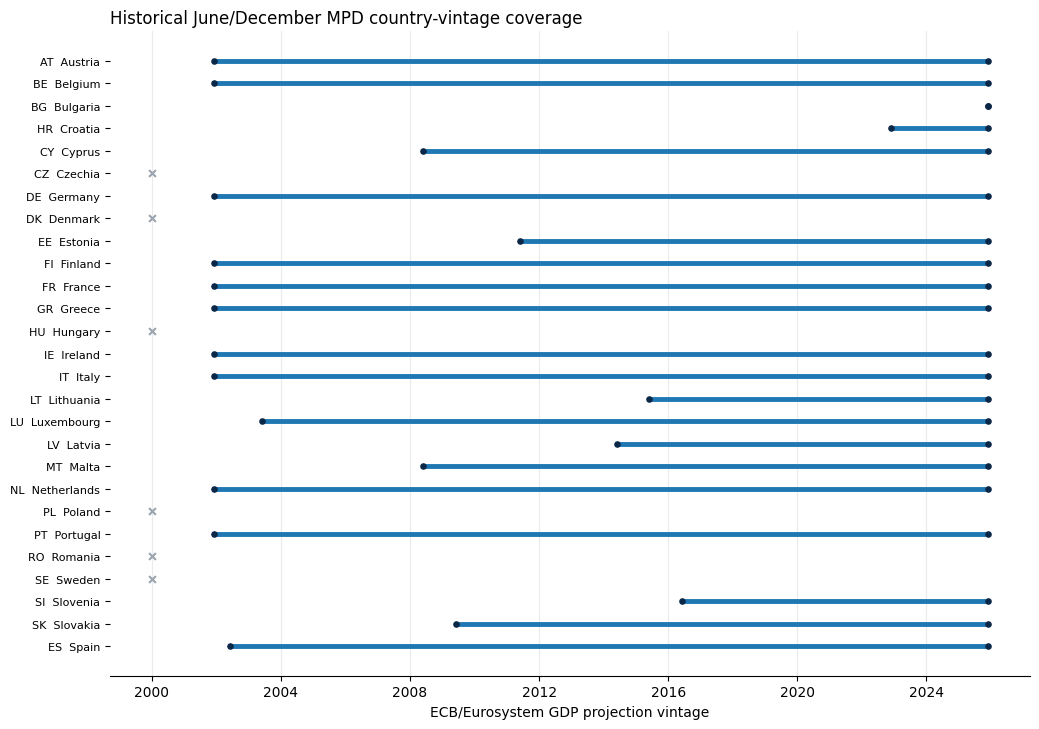

In [3]:
vintage_coverage = (
    forecast.groupby("country")
    .agg(
        first_vintage=("forecast_date", "min"),
        last_vintage=("forecast_date", "max"),
        genuine_vintages=("forecast_date", "nunique"),
        forecast_rows=("forecast_date", "size"),
        first_target=("target_year", "min"),
        last_target=("target_year", "max"),
        horizons=("forecast_horizon", lambda x: ", ".join(map(str, sorted(x.unique())))),
    )
    .reindex(EU)
)
vintage_coverage.index = [f"{code} · {EU[code]}" for code in vintage_coverage.index]
vintage_coverage["first_vintage"] = vintage_coverage["first_vintage"].dt.strftime("%Y-%m")
vintage_coverage["last_vintage"] = vintage_coverage["last_vintage"].dt.strftime("%Y-%m")
display(vintage_coverage.fillna("ECB country forecast unavailable"))

timeline = forecast.groupby("country")["forecast_date"].agg(["min", "max", "nunique"]).reindex(EU)
fig, ax = plt.subplots(figsize=(10.5, 7.4))
y = np.arange(len(EU))[::-1]
for yi, (country, row) in zip(y, timeline.iterrows()):
    if pd.notna(row["min"]):
        ax.plot([row["min"], row["max"]], [yi, yi], color="#1f77b4", linewidth=3.5,
                solid_capstyle="round")
        ax.scatter([row["min"], row["max"]], [yi, yi], color="#0b2748", s=14, zorder=3)
    else:
        ax.scatter(pd.Timestamp("2000-01-01"), yi, marker="x", color="#9aa4af", s=24)
ax.set_yticks(y)
ax.set_yticklabels([f"{c}  {name}" for c, name in EU.items()], fontsize=8)
ax.set_xlabel("ECB/Eurosystem GDP projection vintage")
ax.set_title("Historical June/December MPD country-vintage coverage", loc="left")
ax.grid(axis="x", alpha=0.25)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()


## 2. Matched forecast–outcome observations and long-run anchors

Each retained row is one country × genuine vintage × target year × derived horizon.
The first table exposes the actual analysis records. The following tables show matched
row/target-year counts and the country-specific realized-history span used for the common
long-run anchor at every horizon.


In [4]:
audit_columns = [
    "country", "forecast_date", "target_year", "forecast_horizon",
    "forecast_gdp_growth", "realized_gdp_growth", "country_long_run_average",
    "forecast_deviation", "realized_deviation", "moderation_gap",
]
display(analysis_data[audit_columns].head(18).style.format({
    "forecast_date": lambda x: x.strftime("%Y-%m"),
    "forecast_gdp_growth": "{:.2f}", "realized_gdp_growth": "{:.2f}",
    "country_long_run_average": "{:.2f}", "forecast_deviation": "{:.2f}",
    "realized_deviation": "{:.2f}", "moderation_gap": "{:.2f}",
}).set_caption("First 18 matched forecast-vintage observations"))

matched_rows = analysis_data.pivot_table(
    index="country", columns="forecast_horizon", values="forecast_date", aggfunc="size"
).reindex(index=EU, columns=HORIZONS)
matched_years = analysis_data.pivot_table(
    index="country", columns="forecast_horizon", values="target_year", aggfunc="nunique"
).reindex(index=EU, columns=HORIZONS)
counts = pd.concat({"forecast rows": matched_rows, "target-year clusters": matched_years}, axis=1)
counts.index = [f"{c} · {EU[c]}" for c in counts.index]
display(counts.fillna("—").style.set_caption("Matched sample size by country and derived horizon"))

history_audit = long_run.copy()
history_audit["country_name"] = history_audit["country"].map(EU)
history_audit["years_used"] = (
    history_audit["long_run_start"].astype(int).astype(str)
    + "–" + history_audit["long_run_end"].astype(int).astype(str)
)
history_audit = history_audit[
    ["country", "country_name", "years_used", "long_run_n", "country_long_run_average"]
]
display(history_audit.style.format({"country_long_run_average": "{:.2f}"})
        .set_caption("Longest consistent realized real-GDP-growth history used for each anchor"))


,country,forecast_date,target_year,forecast_horizon,forecast_gdp_growth,realized_gdp_growth,country_long_run_average,forecast_deviation,realized_deviation,moderation_gap
0,AT,2001-12,2002,1,0.90,1.48,1.59,0.69,0.11,-0.58
1,AT,2001-12,2003,2,2.30,1.14,1.59,0.71,0.45,-0.26
2,AT,2002-06,2003,1,2.40,1.14,1.59,0.81,0.45,-0.36
3,AT,2002-06,2004,2,2.60,2.57,1.59,1.01,0.98,-0.03
4,AT,2002-12,2003,1,1.60,1.14,1.59,0.01,0.45,0.44
5,AT,2002-12,2004,2,2.20,2.57,1.59,0.61,0.98,0.37
6,AT,2003-06,2004,1,1.60,2.57,1.59,0.01,0.98,0.97
7,AT,2003-06,2005,2,2.50,2.32,1.59,0.91,0.73,-0.18
8,AT,2003-12,2004,1,1.60,2.57,1.59,0.01,0.98,0.97
9,AT,2003-12,2005,2,2.50,2.32,1.59,0.91,0.73,-0.18


,country,country_name,years_used,long_run_n,country_long_run_average
0,AT,Austria,1996–2025,30,1.59
1,BE,Belgium,1996–2025,30,1.78
2,BG,Bulgaria,1996–2025,30,2.43
3,CY,Cyprus,1996–2025,30,3.32
4,CZ,Czechia,1996–2025,30,2.26
5,DE,Germany,1992–2025,34,1.19
6,DK,Denmark,1967–2025,59,2.20
7,EE,Estonia,1996–2025,30,3.50
8,ES,Spain,1996–2025,30,2.09
9,FI,Finland,1981–2025,45,1.85


## 3. How consecutive forecast snapshots changed

This diagnostic explicitly compares every retained forecast with the previous genuine
June/December forecast for the same country and target year. It verifies that the panel
contains historical snapshots and shows their revision path. Revisions are informative,
but they are not a substitute for the moderation gap: the research question ultimately
requires comparing each vintage with the realized target-year outcome.


,revisions,countries,target_years,mean_revision,mean_absolute_revision,median_absolute_revision
transition,,,,,,
1→1,371,20,23,-0.54,0.82,0.50
2→1,362,20,23,0.03,0.63,0.30
2→2,351,20,22,-0.10,0.38,0.20
3→2,134,20,7,0.24,0.37,0.20


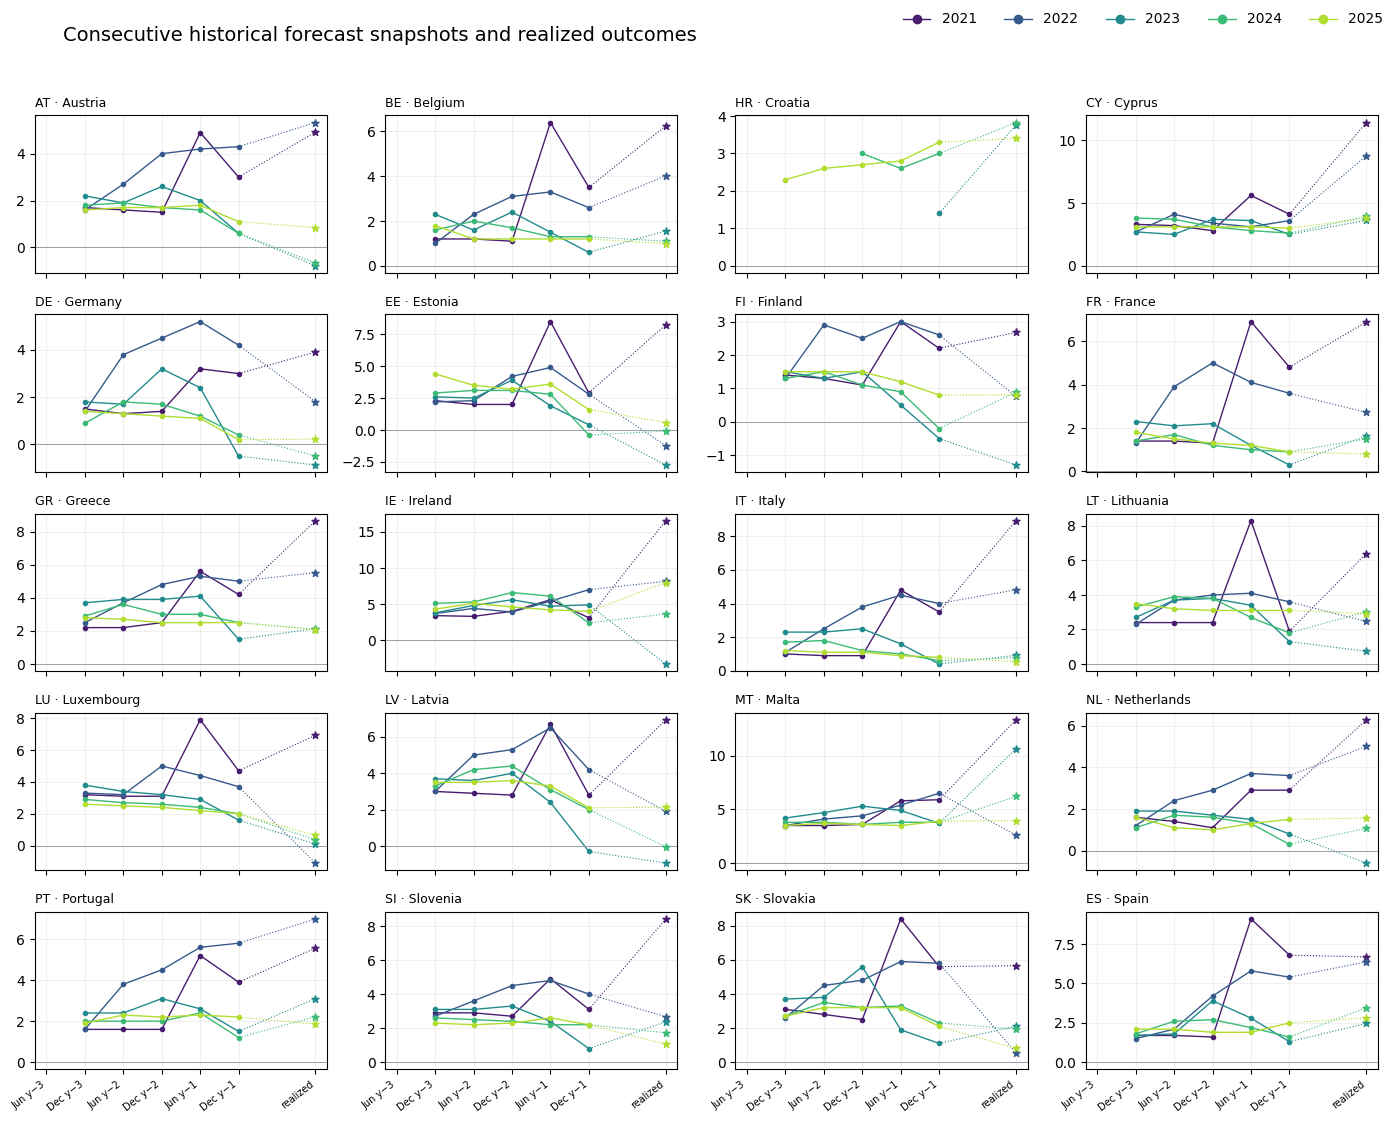

In [5]:
revision_data = analysis_data.sort_values(
    ["country", "target_year", "forecast_date"]
).copy()
revision_group = revision_data.groupby(["country", "target_year"], sort=False)
revision_data["previous_forecast_date"] = revision_group["forecast_date"].shift()
revision_data["previous_forecast"] = revision_group["forecast_gdp_growth"].shift()
revision_data["previous_horizon"] = revision_group["forecast_horizon"].shift()
revision_data["forecast_revision"] = (
    revision_data["forecast_gdp_growth"] - revision_data["previous_forecast"]
)
revision_data["absolute_revision"] = revision_data["forecast_revision"].abs()
revision_pairs = revision_data.dropna(subset=["previous_forecast"]).copy()
revision_pairs["transition"] = (
    revision_pairs["previous_horizon"].astype(int).astype(str)
    + "→" + revision_pairs["forecast_horizon"].astype(int).astype(str)
)
revision_summary = revision_pairs.groupby("transition").agg(
    revisions=("forecast_revision", "size"),
    countries=("country", "nunique"),
    target_years=("target_year", "nunique"),
    mean_revision=("forecast_revision", "mean"),
    mean_absolute_revision=("absolute_revision", "mean"),
    median_absolute_revision=("absolute_revision", "median"),
).sort_index()
display(revision_summary.style.format({
    "mean_revision": "{:.2f}", "mean_absolute_revision": "{:.2f}",
    "median_absolute_revision": "{:.2f}",
}).set_caption("Consecutive-vintage GDP-growth revisions (percentage points)"))

recent_targets = list(range(max(analysis_data["target_year"].max() - 4, 2000),
                            analysis_data["target_year"].max() + 1))
trajectory = analysis_data.loc[analysis_data["target_year"].isin(recent_targets)].copy()
trajectory["lead_position"] = (
    trajectory["forecast_horizon"] + (12 - trajectory["forecast_date"].dt.month) / 12
)
facet_countries = [c for c in EU if c in set(trajectory["country"])]
ncols = 4
nrows = int(np.ceil(len(facet_countries) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.25 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
colors = plt.cm.viridis(np.linspace(0.08, 0.88, len(recent_targets)))
for ax, country in zip(axes, facet_countries):
    country_data = trajectory.loc[trajectory["country"].eq(country)]
    for color, target_year in zip(colors, recent_targets):
        line = country_data.loc[country_data["target_year"].eq(target_year)].sort_values(
            "lead_position", ascending=False
        )
        if line.empty:
            continue
        ax.plot(line["lead_position"], line["forecast_gdp_growth"], "o-",
                color=color, linewidth=1.0, markersize=3)
        realized_value = line["realized_gdp_growth"].iloc[0]
        ax.plot([line["lead_position"].min(), 0],
                [line["forecast_gdp_growth"].iloc[-1], realized_value],
                linestyle=":", color=color, linewidth=0.8)
        ax.scatter(0, realized_value, marker="*", color=color, s=28, zorder=3)
    ax.axhline(0, color="#8b949e", linewidth=0.6)
    ax.set_title(f"{country} · {EU[country]}", fontsize=9, loc="left")
    ax.grid(alpha=0.18)
for ax in axes[len(facet_countries):]:
    ax.axis("off")
for ax in axes[-ncols:]:
    ax.set_xticks([3.5, 3, 2.5, 2, 1.5, 1, 0])
    ax.set_xticklabels(["Jun y−3", "Dec y−3", "Jun y−2", "Dec y−2",
                        "Jun y−1", "Dec y−1", "realized"], rotation=38, ha="right", fontsize=7)
for ax in axes:
    if ax.axison:
        ax.set_xlim(3.65, -0.15)
fig.suptitle("Consecutive historical forecast snapshots and realized outcomes",
             x=0.05, ha="left", fontsize=14)
handles = [plt.Line2D([0], [0], color=c, marker="o", linewidth=1, label=str(y))
           for c, y in zip(colors, recent_targets)]
fig.legend(handles=handles, loc="upper right", ncol=len(recent_targets), frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 4. Forecast GDP growth versus realized GDP growth through time

These plots show the underlying GDP-growth numbers rather than deviations from the
long-run average. Each country has its own facet. For every target year and horizon, the realized outcome is compared with every genuine
June and December forecast vintage available in the corresponding forecast year. In the
retrieved MPD history, matched 3-year country projections are December-only; the 3-year
facets therefore show no June line and display `Jun —` in their latest-value label. The label inside each facet gives the latest
target year's realized, June-forecast, and December-forecast values.

For example, in the 1-year chart, the June and December points for target year 2025 are
the forecasts published in June and December 2024; the black point is realized 2025 GDP
growth. The analogous alignment is used for the 2- and 3-year charts.


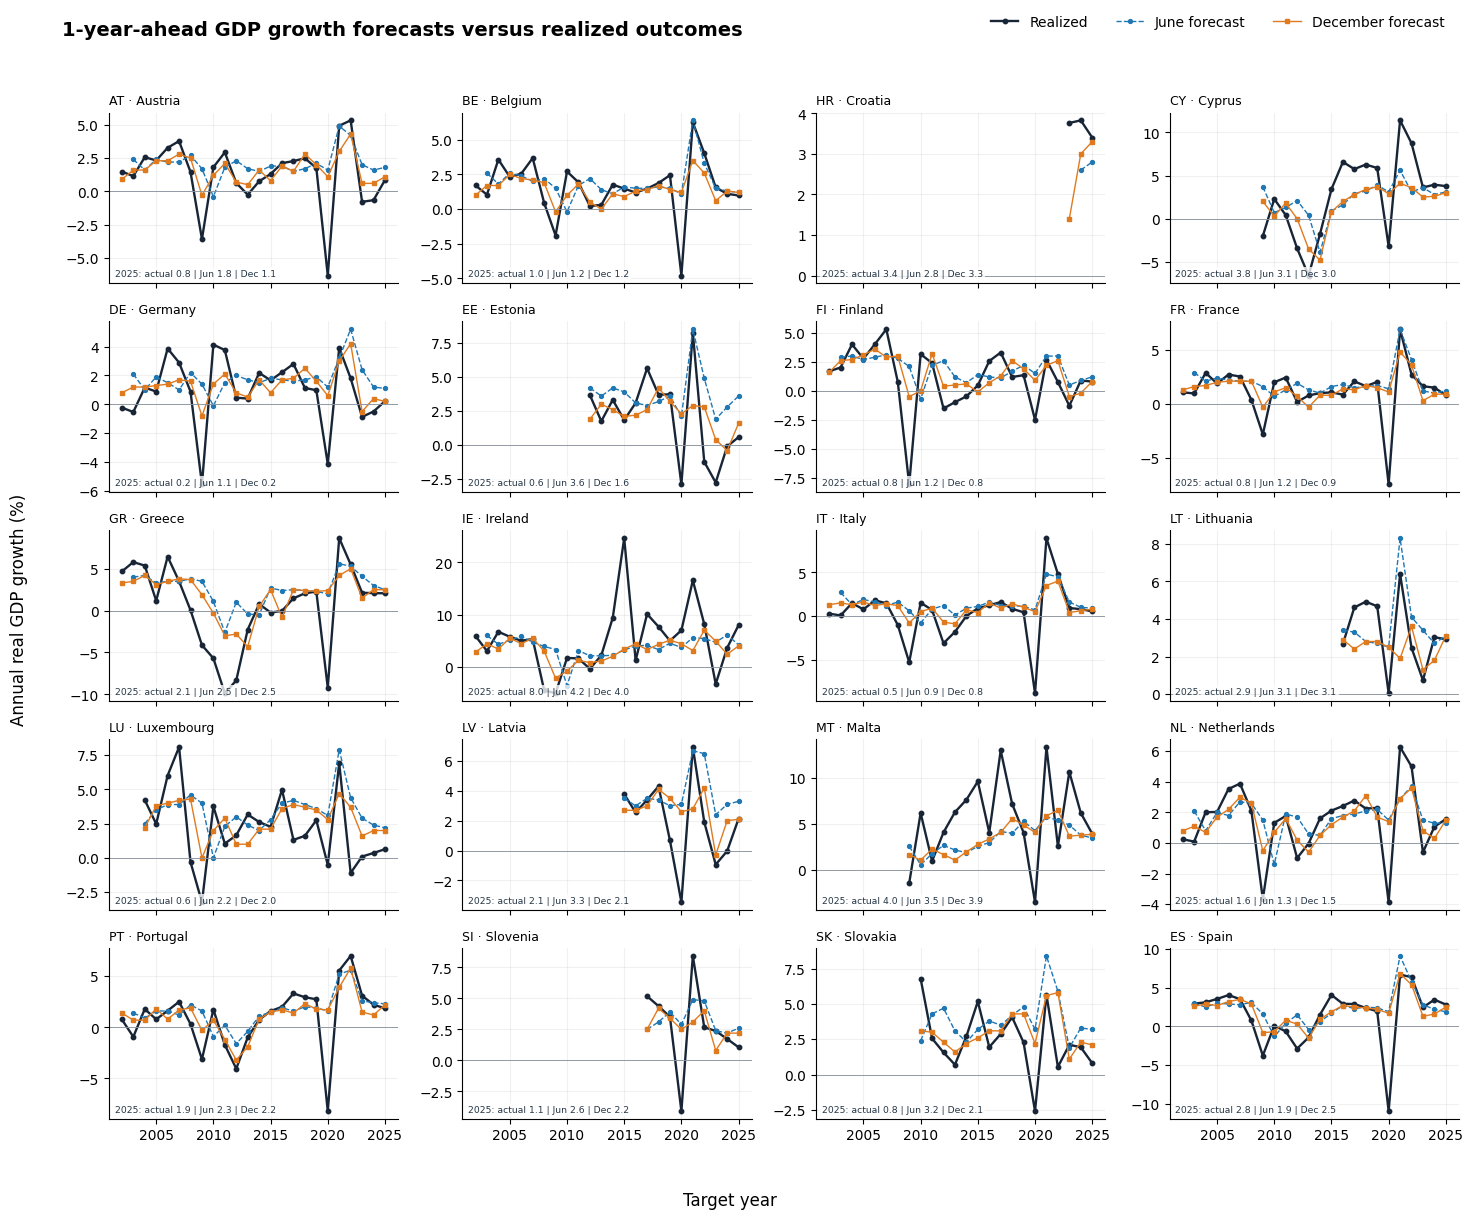

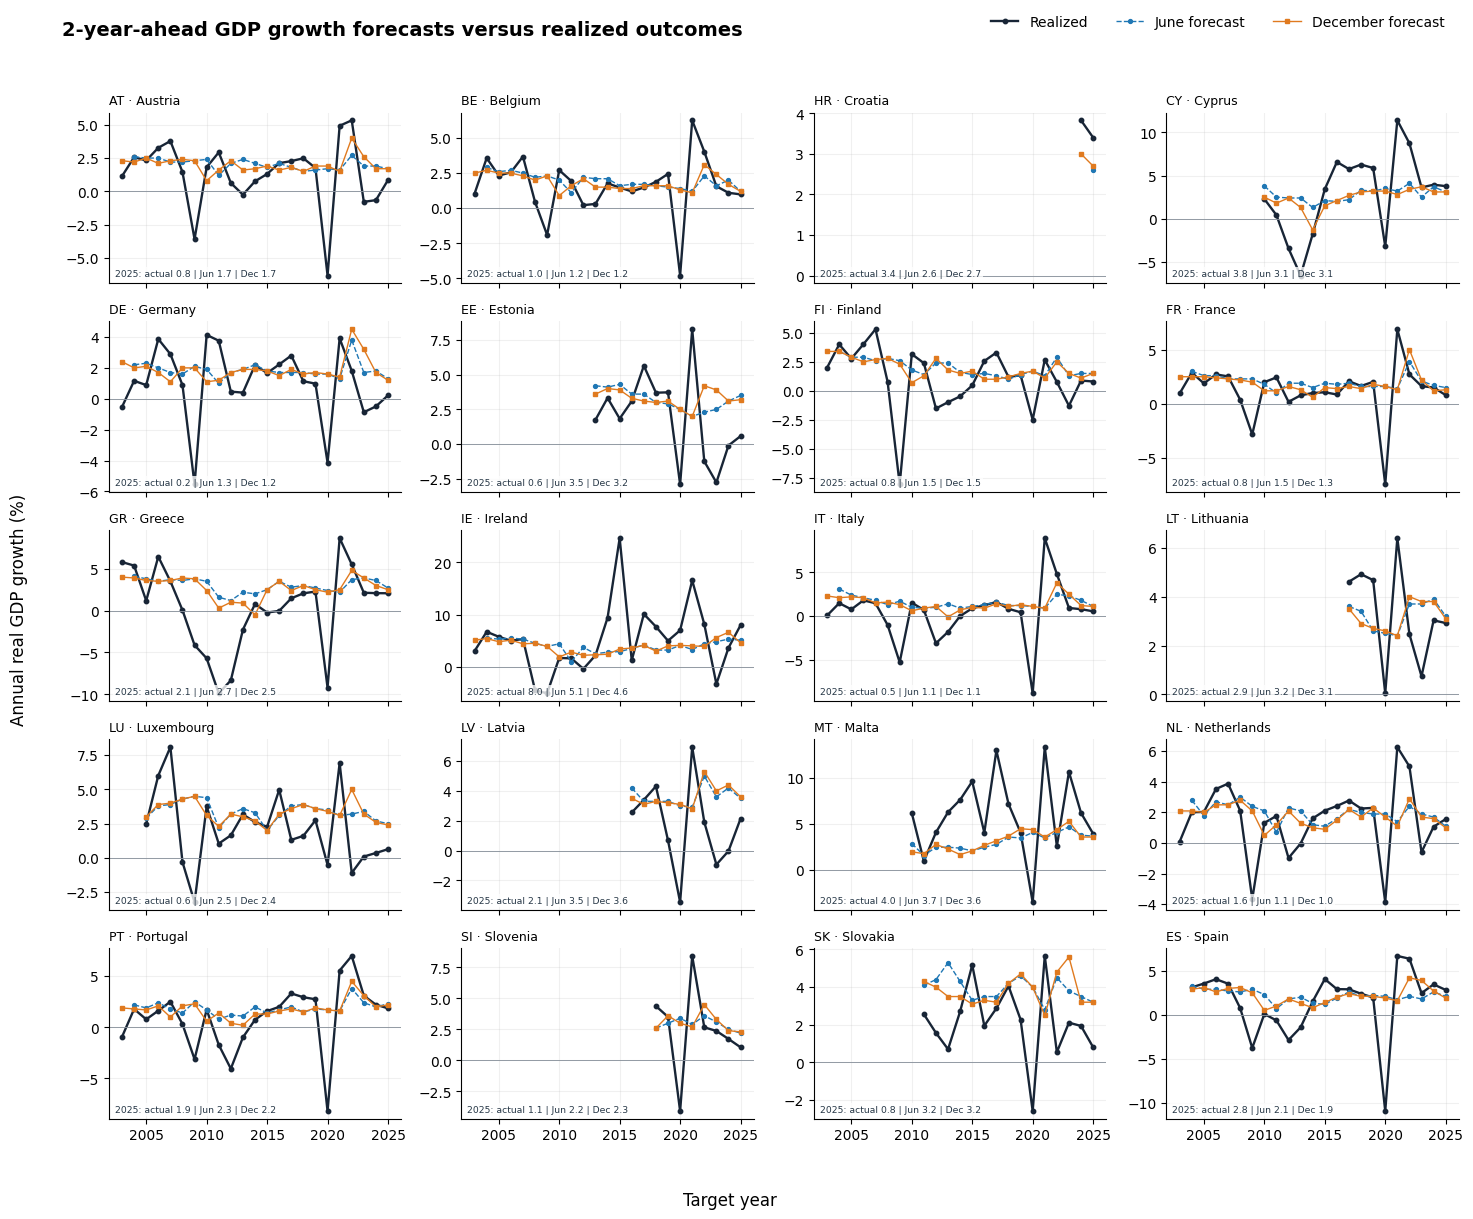

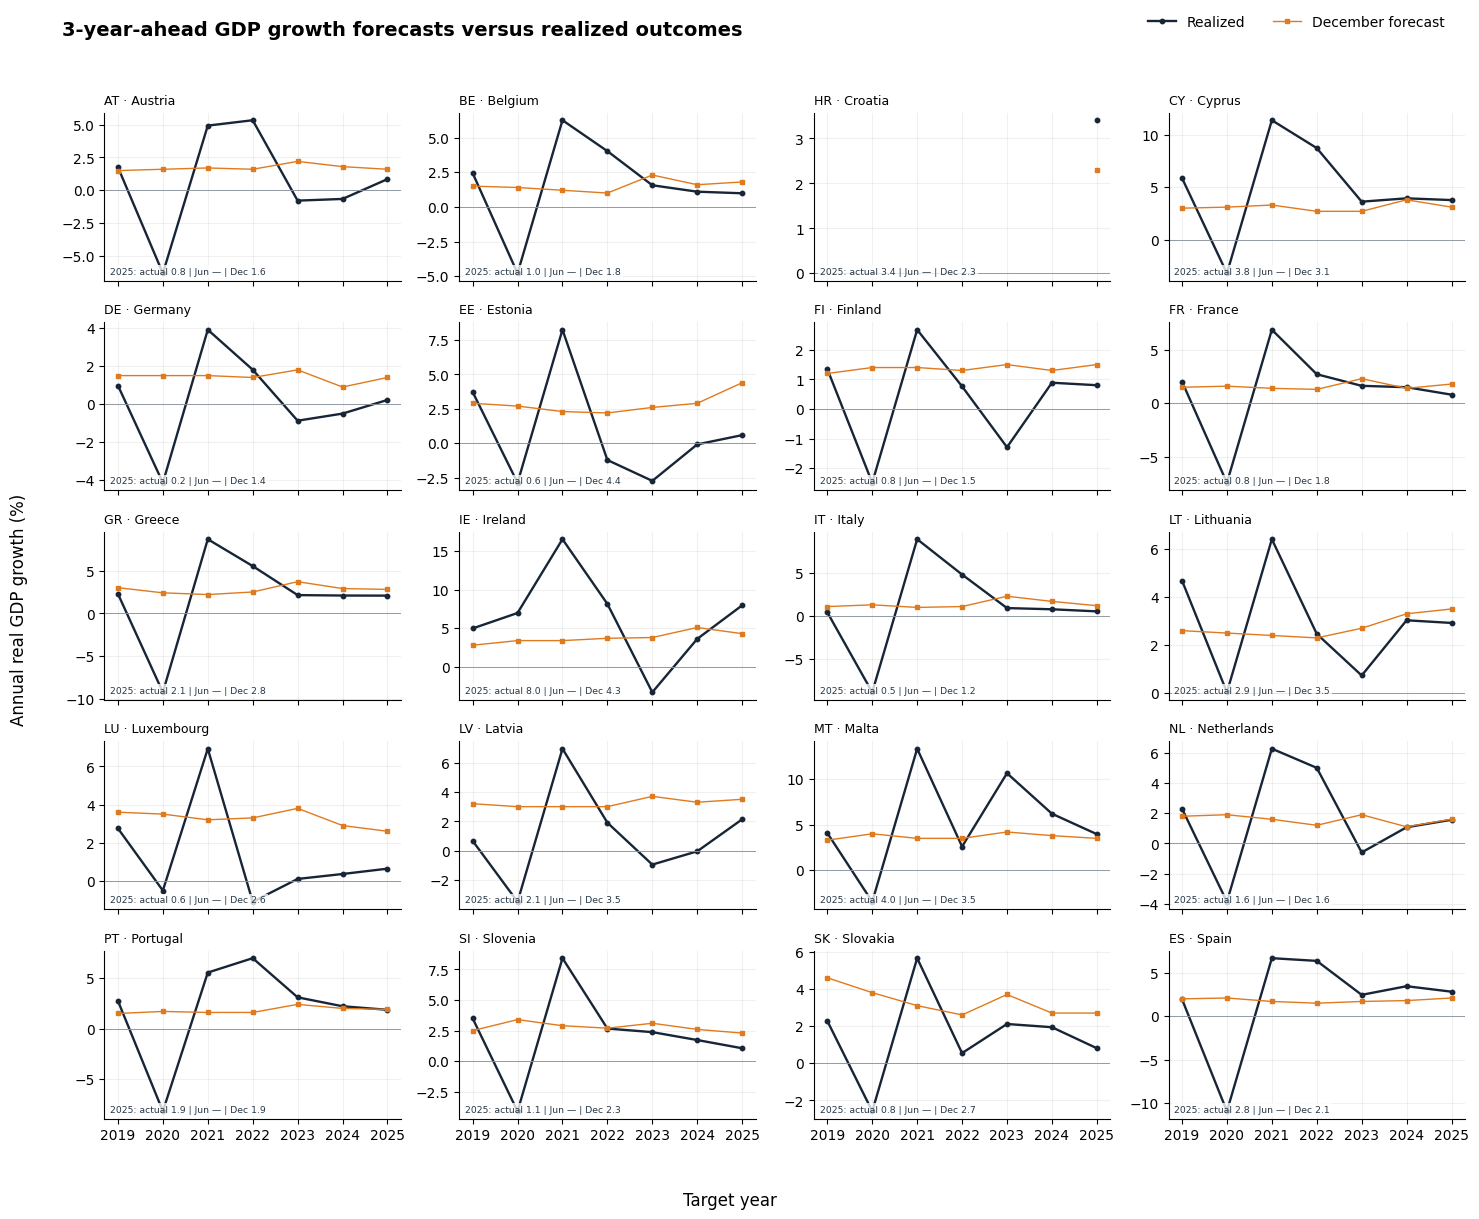

In [6]:
matched_countries = [c for c in EU if c in set(analysis_data["country"])]


def plot_forecast_outcome_history(horizon):
    panel = analysis_data.loc[analysis_data["forecast_horizon"].eq(horizon)].copy()
    ncols = 4
    nrows = int(np.ceil(len(matched_countries) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(15, 2.45 * nrows), sharex=True, squeeze=False
    )
    axes = axes.ravel()

    for ax, country in zip(axes, matched_countries):
        country_panel = panel.loc[panel["country"].eq(country)].copy()
        realized_line = (
            country_panel[["target_year", "realized_gdp_growth"]]
            .drop_duplicates("target_year")
            .sort_values("target_year")
        )
        june_line = country_panel.loc[
            country_panel["forecast_date"].dt.month.eq(6),
            ["target_year", "forecast_gdp_growth"],
        ].sort_values("target_year")
        december_line = country_panel.loc[
            country_panel["forecast_date"].dt.month.eq(12),
            ["target_year", "forecast_gdp_growth"],
        ].sort_values("target_year")

        ax.plot(
            realized_line["target_year"], realized_line["realized_gdp_growth"],
            color="#182536", marker="o", markersize=3.2, linewidth=1.7,
            label="Realized",
        )
        if not june_line.empty:
            ax.plot(
                june_line["target_year"], june_line["forecast_gdp_growth"],
                color="#1f77b4", marker="o", markersize=2.8, linewidth=1.0,
                linestyle="--", label="June forecast",
            )
        if not december_line.empty:
            ax.plot(
                december_line["target_year"], december_line["forecast_gdp_growth"],
                color="#e07a1f", marker="s", markersize=2.8, linewidth=1.0,
                label="December forecast",
            )
        ax.axhline(0, color="#8b949e", linewidth=0.65)
        ax.set_title(f"{country} · {EU[country]}", fontsize=9, loc="left")
        ax.grid(alpha=0.18)
        ax.spines[["top", "right"]].set_visible(False)

        if not realized_line.empty:
            latest_year = int(realized_line["target_year"].max())
            realized_latest = realized_line.loc[
                realized_line["target_year"].eq(latest_year), "realized_gdp_growth"
            ]
            june_latest = june_line.loc[
                june_line["target_year"].eq(latest_year), "forecast_gdp_growth"
            ]
            december_latest = december_line.loc[
                december_line["target_year"].eq(latest_year), "forecast_gdp_growth"
            ]

            def latest_text(values):
                return "—" if values.empty else f"{values.iloc[0]:.1f}"

            ax.text(
                0.02, 0.04,
                f"{latest_year}: actual {latest_text(realized_latest)} | "
                f"Jun {latest_text(june_latest)} | Dec {latest_text(december_latest)}",
                transform=ax.transAxes, fontsize=6.7, color="#263746",
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78,
                      "pad": 1.5},
            )

    for ax in axes[len(matched_countries):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.985, 0.995), ncol=len(labels), frameon=False)
    fig.suptitle(
        f"{horizon}-year-ahead GDP growth forecasts versus realized outcomes",
        x=0.055, ha="left", fontsize=14, fontweight="bold",
    )
    fig.supxlabel("Target year")
    fig.supylabel("Annual real GDP growth (%)")
    fig.tight_layout(rect=[0.025, 0.025, 1, 0.96])
    plt.show()


for horizon in HORIZONS:
    plot_forecast_outcome_history(horizon)


## 5. The central result, shown directly

Countries remain the unit of analysis. The chart first averages within each country,
then gives every sufficiently observed country equal weight. The distance between the
orange realized bar and blue forecast bar is exactly the moderation gap: positive means
the forecasts stayed closer to the country-specific long-run growth anchor.


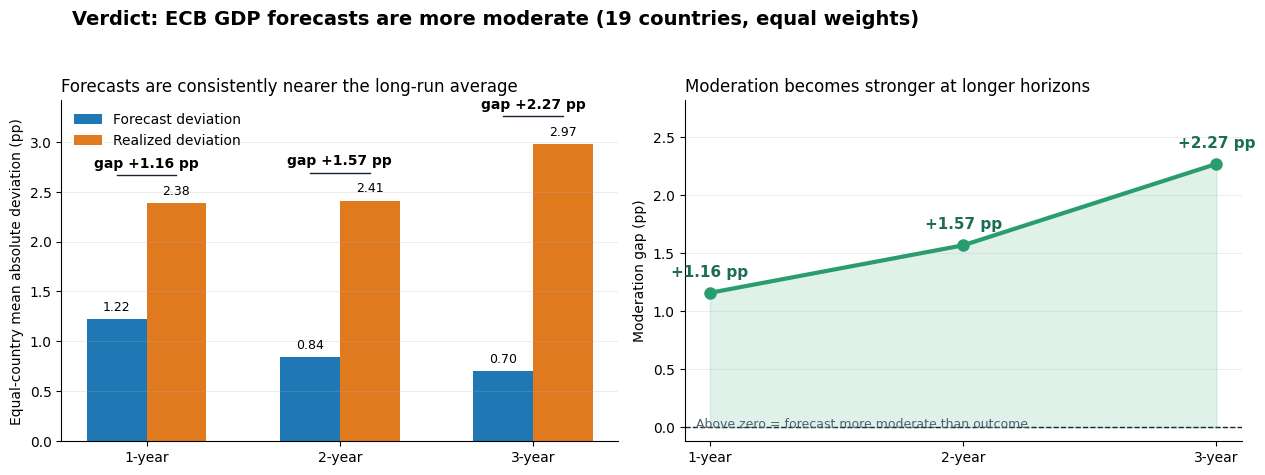

In [7]:
country_descriptive = analysis_data.groupby(
    ["country", "forecast_horizon"]
).agg(
    mean_forecast_deviation=("forecast_deviation", "mean"),
    mean_realized_deviation=("realized_deviation", "mean"),
    mean_gap=("moderation_gap", "mean"),
    target_years=("target_year", "nunique"),
).reset_index()

# Use one balanced country set so the horizon comparison cannot be driven by
# changing country composition. This is the same set used in the final summary.
eligible_sets = [
    set(country_descriptive.loc[
        country_descriptive["forecast_horizon"].eq(h)
        & country_descriptive["target_years"].ge(MIN_TARGET_YEARS),
        "country",
    ])
    for h in HORIZONS
]
balanced_descriptive_countries = set.intersection(*eligible_sets)
balanced_descriptive = country_descriptive.loc[
    country_descriptive["country"].isin(balanced_descriptive_countries)
]
equal_country = balanced_descriptive.groupby("forecast_horizon").agg(
    forecast_deviation=("mean_forecast_deviation", "mean"),
    realized_deviation=("mean_realized_deviation", "mean"),
    moderation_gap=("mean_gap", "mean"),
).reindex(HORIZONS)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
x = np.arange(len(HORIZONS))
width = 0.31
forecast_bars = axes[0].bar(
    x - width / 2, equal_country["forecast_deviation"], width,
    label="Forecast deviation", color="#1f77b4",
)
realized_bars = axes[0].bar(
    x + width / 2, equal_country["realized_deviation"], width,
    label="Realized deviation", color="#e07a1f",
)
for i, horizon in enumerate(HORIZONS):
    forecast_value = equal_country.loc[horizon, "forecast_deviation"]
    realized_value = equal_country.loc[horizon, "realized_deviation"]
    gap = equal_country.loc[horizon, "moderation_gap"]
    axes[0].text(i - width / 2, forecast_value + 0.06, f"{forecast_value:.2f}",
                 ha="center", va="bottom", fontsize=9)
    axes[0].text(i + width / 2, realized_value + 0.06, f"{realized_value:.2f}",
                 ha="center", va="bottom", fontsize=9)
    bracket_y = max(forecast_value, realized_value) + 0.28
    axes[0].plot([i - width / 2, i + width / 2], [bracket_y, bracket_y],
                 color="#182536", linewidth=1)
    axes[0].text(i, bracket_y + 0.05, f"gap +{gap:.2f} pp",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_xticks(x, ["1-year", "2-year", "3-year"])
axes[0].set_ylabel("Equal-country mean absolute deviation (pp)")
axes[0].set_title("Forecasts are consistently nearer the long-run average", loc="left")
axes[0].legend(frameon=False, loc="upper left")
axes[0].grid(axis="y", alpha=0.22)

gap_values = equal_country["moderation_gap"].to_numpy()
axes[1].plot(x, gap_values, "o-", color="#2a9d6f", linewidth=3, markersize=8)
axes[1].fill_between(x, 0, gap_values, color="#2a9d6f", alpha=0.14)
axes[1].axhline(0, color="#182536", linestyle="--", linewidth=1)
for i, value in enumerate(gap_values):
    axes[1].annotate(
        f"+{value:.2f} pp",
        (i, value), xytext=(0, 12), textcoords="offset points",
        ha="center", fontsize=11, fontweight="bold", color="#1c6e52",
    )
axes[1].set_xticks(x, ["1-year", "2-year", "3-year"])
axes[1].set_ylabel("Moderation gap (pp)")
axes[1].set_ylim(bottom=min(-0.12, gap_values.min() - 0.25),
                 top=gap_values.max() + 0.55)
axes[1].set_title("Moderation becomes stronger at longer horizons", loc="left")
axes[1].text(
    0.02, 0.04, "Above zero = forecast more moderate than outcome",
    transform=axes[1].transAxes, fontsize=9, color="#52606d",
)
axes[1].grid(axis="y", alpha=0.22)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(
    f"Verdict: ECB GDP forecasts are more moderate ({len(balanced_descriptive_countries)} countries, equal weights)",
    x=0.06, ha="left", fontsize=14, fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 6. Country-level bootstrap inference and final synthesis

The primary analysis below remains non-pooled. Target years—not individual vintage rows—
are resampled so that two genuine vintages aimed at the same outcome stay together.
The horizon summary first reduces each country to one statistic and then weights countries
equally.


VERDICT
-------
Across the balanced, equal-country summary, forecasts are generally closer to long-run growth than outcomes at all three horizons. The estimated moderation gap strengthens monotonically from 1 to 3 years. Equal-country mean moderation gaps are 1.16, 1.57, and 2.27 percentage points at 1-, 2-, and 3-year horizons.
Strongest evidence: Cyprus (2.64 pp; 3/3 positive CIs), Malta (2.29 pp; 3/3 positive CIs), Estonia (2.23 pp; 3/3 positive CIs).
Weakest evidence: Lithuania (0.62 pp; 1/3 positive CIs), France (0.98 pp; 1/3 positive CIs), Italy (1.56 pp; 2/3 positive CIs).
Limited-data results: Croatia (1y: 3 target years), Croatia (2y: 2 target years), Croatia (3y: 1 target year). Bulgaria has ECB vintages but no realized target-year match yet. 7 adequately sized country–horizon intervals still cross zero.
Interpretation: positive gaps show empirical moderation relative to each country's long-run growth rate; they do not establish intentional conservatism.

EQUAL-COUNTRY HORIZO

,Horizon,Countries,Equal-wt |F−LR|,Equal-wt |R−LR|,Equal-wt gap,95% CI,Country means > 0,Δ vs 1y,p (one-sided)
0,1-year,19,1.22,2.38,1.16,"[0.95, 1.39]",100%,0.00,<0.001
1,2-year,19,0.84,2.41,1.57,"[1.33, 1.85]",100%,0.41,<0.001
2,3-year,19,0.70,2.97,2.27,"[1.95, 2.59]",100%,1.11,<0.001



COUNTRY × HORIZON RESULTS


,Country,H,Matched / years,LR avg,LR years,|F−LR|,|R−LR|,Gap,95% CI,Moderate %,p (one-sided),Evidence
0,AT · Austria,1y,47 / 24,1.59,1996–2025,0.72,1.68,0.96,"[0.34, 1.75]",74%,0.010,More moderate
1,AT · Austria,2y,45 / 23,1.59,1996–2025,0.50,1.74,1.25,"[0.58, 2.07]",78%,0.002,More moderate
2,AT · Austria,3y,7 / 7,1.59,1996–2025,0.15,2.93,2.78,"[1.23, 4.71]",100%,0.004,More moderate
3,BE · Belgium,1y,47 / 24,1.78,1996–2025,0.70,1.36,0.66,"[0.20, 1.32]",70%,0.024,More moderate
4,BE · Belgium,2y,45 / 23,1.78,1996–2025,0.47,1.40,0.93,"[0.38, 1.59]",76%,0.004,More moderate
...,...,...,...,...,...,...,...,...,...,...,...,...
76,SK · Slovakia,2y,30 / 15,3.29,1996–2025,0.70,1.80,1.10,"[0.48, 1.85]",73%,0.005,More moderate
77,SK · Slovakia,3y,7 / 7,3.29,1996–2025,0.61,2.43,1.81,"[0.78, 3.14]",86%,0.005,More moderate
78,ES · Spain,1y,46 / 23,2.09,1996–2025,1.29,2.44,1.15,"[0.24, 2.45]",72%,0.039,More moderate
79,ES · Spain,2y,44 / 22,2.09,1996–2025,0.61,2.51,1.90,"[0.86, 3.27]",91%,0.005,More moderate



COUNTRY-LEVEL EVIDENCE (POSITIVE = FORECAST MORE MODERATE)


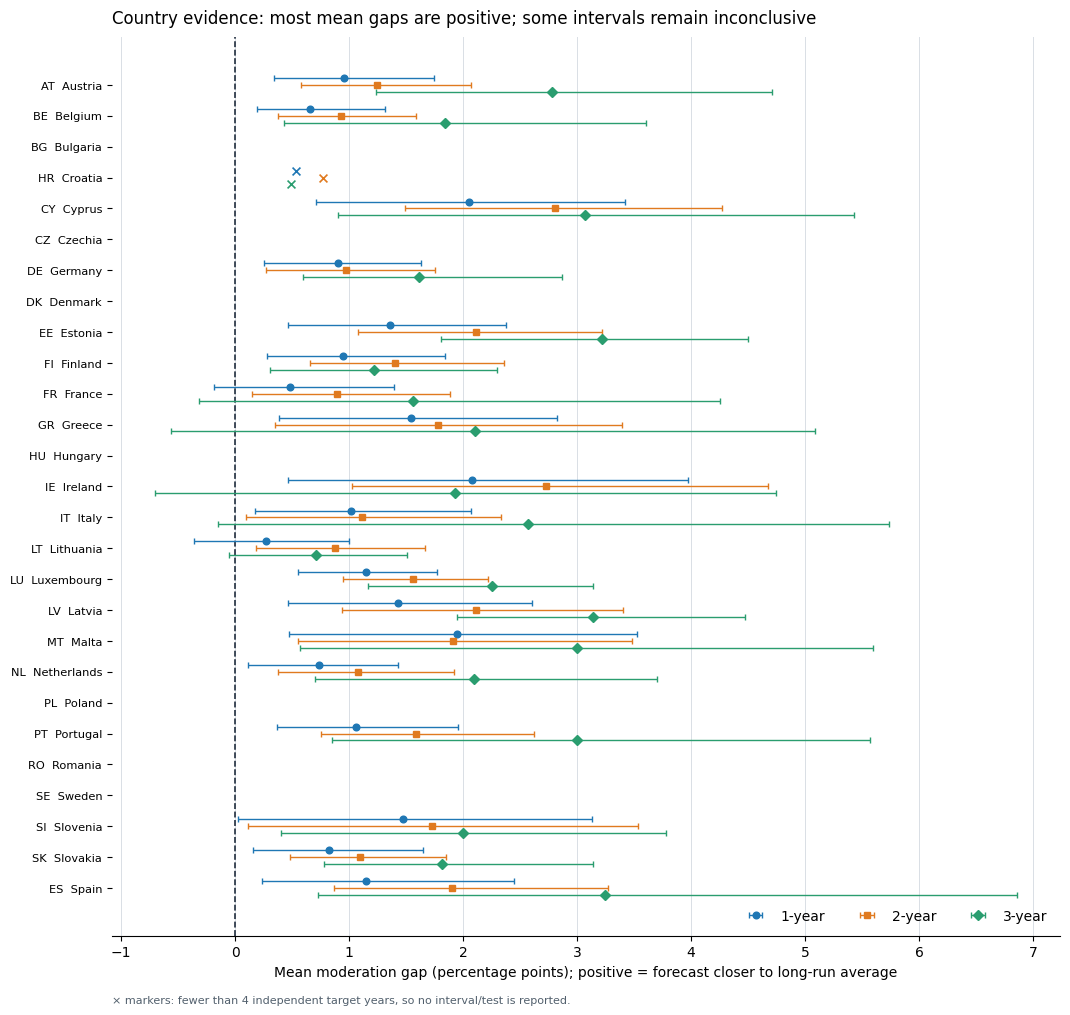

In [8]:
def cluster_bootstrap(group, seed):
    """Target-year cluster bootstrap CI and one-sided centered-bootstrap test."""
    clusters = [
        part["moderation_gap"].to_numpy(dtype=float)
        for _, part in group.groupby("target_year", sort=True)
    ]
    observed = group["moderation_gap"].mean()
    if len(clusters) < MIN_TARGET_YEARS:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot_means = np.empty(BOOTSTRAPS)
    for b in range(BOOTSTRAPS):
        chosen = rng.integers(0, len(clusters), size=len(clusters))
        boot_means[b] = np.concatenate([clusters[i] for i in chosen]).mean()
    ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
    null_means = boot_means - observed
    p_greater = (1 + np.count_nonzero(null_means >= observed)) / (BOOTSTRAPS + 1)
    return float(ci_low), float(ci_high), float(p_greater)


history = long_run.set_index("country")
mpd_country_coverage = set(
    mpd_raw.loc[
        mpd_raw["REF_AREA"].isin(EU)
        & mpd_raw["PD_SEAS_EX"].astype(str).str.fullmatch(r"[AG]\d{2}")
        & pd.to_numeric(mpd_raw["OBS_VALUE"], errors="coerce").notna(),
        "REF_AREA",
    ]
)

rows = []
for country_index, (country, country_name) in enumerate(EU.items()):
    hrow = history.loc[country]
    for horizon in HORIZONS:
        group = analysis_data.loc[
            analysis_data["country"].eq(country)
            & analysis_data["forecast_horizon"].eq(horizon)
        ]
        base = {
            "country": country,
            "country_name": country_name,
            "horizon": horizon,
            "n_obs": len(group),
            "n_target_years": group["target_year"].nunique(),
            "long_run_average": hrow["country_long_run_average"],
            "long_run_start": int(hrow["long_run_start"]),
            "long_run_end": int(hrow["long_run_end"]),
        }
        if group.empty:
            reason = (
                "ECB country forecast unavailable"
                if country not in mpd_country_coverage
                else "No forecast–outcome match yet"
            )
            rows.append(base | {
                "mean_forecast_deviation": np.nan,
                "mean_realized_deviation": np.nan,
                "mean_gap": np.nan,
                "pct_more_moderate": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "p_greater": np.nan,
                "evidence": reason,
            })
            continue
        ci_low, ci_high, p_greater = cluster_bootstrap(
            group, 20260720 + country_index * 10 + horizon
        )
        if group["target_year"].nunique() < MIN_TARGET_YEARS:
            evidence = f"Insufficient (<{MIN_TARGET_YEARS} target years)"
        elif ci_low > 0 and p_greater < 0.05:
            evidence = "More moderate"
        elif ci_high < 0:
            evidence = "More extreme"
        else:
            evidence = "Inconclusive"
        rows.append(base | {
            "mean_forecast_deviation": group["forecast_deviation"].mean(),
            "mean_realized_deviation": group["realized_deviation"].mean(),
            "mean_gap": group["moderation_gap"].mean(),
            "pct_more_moderate": 100 * group["moderation_gap"].gt(0).mean(),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_greater": p_greater,
            "evidence": evidence,
        })

results = pd.DataFrame(rows)

# Equal-country horizon summary on a balanced, inferentially usable country set.
usable = results.loc[results["n_target_years"].ge(MIN_TARGET_YEARS)]
balanced_countries = set.intersection(*[
    set(usable.loc[usable["horizon"].eq(h), "country"]) for h in HORIZONS
])
summary_rows = []
for horizon in HORIZONS:
    part = usable.loc[
        usable["horizon"].eq(horizon)
        & usable["country"].isin(balanced_countries)
    ].set_index("country").sort_index()
    values = part["mean_gap"].to_numpy(dtype=float)
    observed = values.mean()
    rng = np.random.default_rng(20260780 + horizon)
    draws = rng.choice(values, size=(BOOTSTRAPS, len(values)), replace=True).mean(axis=1)
    ci_low, ci_high = np.quantile(draws, [0.025, 0.975])
    null_draws = draws - observed
    p_greater = (1 + np.count_nonzero(null_draws >= observed)) / (BOOTSTRAPS + 1)
    summary_rows.append({
        "horizon": horizon,
        "countries": len(part),
        "mean_forecast_deviation": part["mean_forecast_deviation"].mean(),
        "mean_realized_deviation": part["mean_realized_deviation"].mean(),
        "mean_gap": observed,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "pct_country_means_positive": 100 * (values > 0).mean(),
        "p_greater": p_greater,
    })
summary = pd.DataFrame(summary_rows)
base_gap = summary.loc[summary["horizon"].eq(1), "mean_gap"].iloc[0]
summary["change_vs_1y"] = summary["mean_gap"] - base_gap


def fmt_num(value, digits=2):
    return "—" if pd.isna(value) else f"{value:.{digits}f}"


def fmt_p(value):
    if pd.isna(value):
        return "—"
    return "<0.001" if value < 0.001 else f"{value:.3f}"


country_display = results.copy()
country_display["Country"] = country_display.apply(
    lambda r: f"{r['country']} · {r['country_name']}", axis=1
)
country_display["H"] = country_display["horizon"].map(lambda x: f"{x}y")
country_display["Matched / years"] = country_display.apply(
    lambda r: f"{int(r['n_obs'])} / {int(r['n_target_years'])}" if r["n_obs"] else "—", axis=1
)
country_display["LR years"] = country_display.apply(
    lambda r: f"{int(r['long_run_start'])}–{int(r['long_run_end'])}", axis=1
)
country_display["LR avg"] = country_display["long_run_average"].map(fmt_num)
country_display["|F−LR|"] = country_display["mean_forecast_deviation"].map(fmt_num)
country_display["|R−LR|"] = country_display["mean_realized_deviation"].map(fmt_num)
country_display["Gap"] = country_display["mean_gap"].map(fmt_num)
country_display["95% CI"] = country_display.apply(
    lambda r: "—" if pd.isna(r["ci_low"]) else f"[{r['ci_low']:.2f}, {r['ci_high']:.2f}]",
    axis=1,
)
country_display["Moderate %"] = country_display["pct_more_moderate"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.0f}%"
)
country_display["p (one-sided)"] = country_display["p_greater"].map(fmt_p)
country_display = country_display[
    ["Country", "H", "Matched / years", "LR avg", "LR years", "|F−LR|",
     "|R−LR|", "Gap", "95% CI", "Moderate %", "p (one-sided)", "evidence"]
].rename(columns={"evidence": "Evidence"})

summary_display = summary.copy()
summary_display["Horizon"] = summary_display["horizon"].map(lambda x: f"{x}-year")
summary_display["Countries"] = summary_display["countries"].astype(int)
summary_display["Equal-wt |F−LR|"] = summary_display["mean_forecast_deviation"].map(fmt_num)
summary_display["Equal-wt |R−LR|"] = summary_display["mean_realized_deviation"].map(fmt_num)
summary_display["Equal-wt gap"] = summary_display["mean_gap"].map(fmt_num)
summary_display["95% CI"] = summary_display.apply(
    lambda r: f"[{r['ci_low']:.2f}, {r['ci_high']:.2f}]", axis=1
)
summary_display["Country means > 0"] = summary_display["pct_country_means_positive"].map(
    lambda x: f"{x:.0f}%"
)
summary_display["Δ vs 1y"] = summary_display["change_vs_1y"].map(fmt_num)
summary_display["p (one-sided)"] = summary_display["p_greater"].map(fmt_p)
summary_display = summary_display[
    ["Horizon", "Countries", "Equal-wt |F−LR|", "Equal-wt |R−LR|",
     "Equal-wt gap", "95% CI", "Country means > 0", "Δ vs 1y", "p (one-sided)"]
]

# One compact country-row coefficient plot; missing combinations have no marker.
plot_rows = results.loc[results["n_obs"].gt(0)].copy()
fig_height = max(8.2, 0.31 * len(EU) + 1.8)
fig, ax = plt.subplots(figsize=(10.8, fig_height))
y_base = {country: len(EU) - 1 - i for i, country in enumerate(EU)}
styles = {
    1: ("#1f77b4", "o", 0.22),
    2: ("#e07a1f", "s", 0.00),
    3: ("#2a9d6f", "D", -0.22),
}
for horizon, (color, marker, offset) in styles.items():
    part = plot_rows.loc[plot_rows["horizon"].eq(horizon)]
    first_label = True
    for _, row in part.iterrows():
        y = y_base[row["country"]] + offset
        label = f"{horizon}-year" if first_label else None
        if pd.notna(row["ci_low"]):
            ax.errorbar(
                row["mean_gap"], y,
                xerr=[[row["mean_gap"] - row["ci_low"]],
                      [row["ci_high"] - row["mean_gap"]]],
                fmt=marker, color=color, ecolor=color, elinewidth=1.0,
                capsize=2.2, markersize=4.8, label=label, zorder=3,
            )
        else:
            ax.scatter(
                row["mean_gap"], y, marker="x", color=color,
                s=32, linewidth=1.2, label=label, zorder=3,
            )
        first_label = False
ax.axvline(0, color="#182536", linewidth=1.15, linestyle="--", zorder=1)
ax.set_yticks(list(y_base.values()))
ax.set_yticklabels([f"{code}  {name}" for code, name in EU.items()], fontsize=8.2)
ax.set_xlabel("Mean moderation gap (percentage points); positive = forecast closer to long-run average")
ax.set_title("Country evidence: most mean gaps are positive; some intervals remain inconclusive", loc="left", pad=10)
ax.grid(axis="x", color="#d9dee5", linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, ncol=3)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.text(
    0.0, -0.075,
    f"× markers: fewer than {MIN_TARGET_YEARS} independent target years, so no interval/test is reported.",
    transform=ax.transAxes, fontsize=8, color="#52606d",
)
fig.tight_layout()

# Dynamic, auditable conclusion language.
gaps = summary.set_index("horizon")["mean_gap"]
if (gaps > 0).all():
    general = "Across the balanced, equal-country summary, forecasts are generally closer to long-run growth than outcomes at all three horizons."
elif (gaps < 0).all():
    general = "Across the balanced, equal-country summary, forecasts are generally farther from long-run growth than outcomes at all three horizons."
else:
    general = "The balanced, equal-country summary is mixed: moderation is not positive at every horizon."
if gaps.loc[1] < gaps.loc[2] < gaps.loc[3]:
    trend = "The estimated moderation gap strengthens monotonically from 1 to 3 years."
elif gaps.loc[1] > gaps.loc[2] > gaps.loc[3]:
    trend = "The estimated moderation gap weakens monotonically from 1 to 3 years."
else:
    trend = "The horizon pattern is not monotonic."

rankable = usable.loc[usable["country"].isin(balanced_countries)].groupby("country").agg(
    avg_gap=("mean_gap", "mean"),
    positive_intervals=("ci_low", lambda x: int((x > 0).sum())),
)
strongest = rankable.sort_values(["positive_intervals", "avg_gap"], ascending=False).head(3)
weakest = rankable.sort_values(["positive_intervals", "avg_gap"], ascending=True).head(3)
strong_text = ", ".join(
    f"{EU[c]} ({row.avg_gap:.2f} pp; {int(row.positive_intervals)}/3 positive CIs)"
    for c, row in strongest.iterrows()
)
weak_text = ", ".join(
    f"{EU[c]} ({row.avg_gap:.2f} pp; {int(row.positive_intervals)}/3 positive CIs)"
    for c, row in weakest.iterrows()
)
limited = results.loc[
    results["n_obs"].gt(0) & results["n_target_years"].lt(MIN_TARGET_YEARS)
]
limited_text = ", ".join(
    f"{EU[r.country]} ({int(r.horizon)}y: {int(r.n_target_years)} target year{'s' if r.n_target_years != 1 else ''})"
    for r in limited.itertuples()
) or "none"
no_match = [
    EU[c] for c in EU
    if c in mpd_country_coverage and not results.loc[results["country"].eq(c), "n_obs"].any()
]
unavailable = [EU[c] for c in EU if c not in mpd_country_coverage]
crossing = int((usable["ci_low"].le(0) & usable["ci_high"].ge(0)).sum())
print("VERDICT")
print("-------")
print(
    f"{general} {trend} Equal-country mean moderation gaps are "
    f"{gaps.loc[1]:.2f}, {gaps.loc[2]:.2f}, and {gaps.loc[3]:.2f} percentage points "
    "at 1-, 2-, and 3-year horizons."
)
print(f"Strongest evidence: {strong_text}.")
print(f"Weakest evidence: {weak_text}.")
print(
    f"Limited-data results: {limited_text}. "
    f"{', '.join(no_match) if no_match else 'No country'} has ECB vintages but no "
    f"realized target-year match yet. {crossing} adequately sized country–horizon "
    "intervals still cross zero."
)
print(
    "Interpretation: positive gaps show empirical moderation relative to each country's "
    "long-run growth rate; they do not establish intentional conservatism."
)

print("\nEQUAL-COUNTRY HORIZON SUMMARY")
display(summary_display)

print("\nCOUNTRY × HORIZON RESULTS")
display(country_display)

print("\nCOUNTRY-LEVEL EVIDENCE (POSITIVE = FORECAST MORE MODERATE)")
plt.show()
